In [1]:
#! pip install diffrax

In [40]:
import jax
import jax.numpy as jnp
import diffrax
from jax import config

config.update("jax_enable_x64", True)

# --- SECTION 1: THE PHYSICS ---
def physics_vf(t, y, args):
    theta, omega = y
    # A damped pendulum
    return jnp.stack([omega, -0.2 * omega - 5.0 * jnp.sin(theta)])

t0, t1, y0 = 0.0, 5.0, jnp.array([jnp.pi/4, 0.0])
term = diffrax.ODETerm(physics_vf)
sol = diffrax.diffeqsolve(term, diffrax.Tsit5(), t0=t0, t1=t1, dt0=0.01, y0=y0, 
                          saveat=diffrax.SaveAt(ts=jnp.linspace(t0, t1, 100)))

# --- SECTION 2: THE PURE JAX POLYNOMIAL ---
def ga_solution_fn_1(t, coeffs):
    """
    Evaluates y = c0 + c1*t + c2*t^2 ... using pure JAX.
    We scale 't' to [0, 1] to prevent the powers from exploding too early.
    """
    t_scaled = (t - t0) / (t1 - t0)
    powers = jnp.arange(len(coeffs))
    return jnp.sum(coeffs * (t_scaled ** powers))

def ga_solution_fn(t, coeffs):
    # coeffs[0] is the DC offset
    a0 = coeffs[0]
    
    # Take the remaining coefficients and ensure they are paired
    # If len(coeffs) is 49, 'rest' will be 48, which reshapes to (24, 2)
    rest = coeffs[1:]
    pairs = rest.reshape(-1, 2)
    
    n_terms = pairs.shape[0]
    n = jnp.arange(1, n_terms + 1)
    
    # We define the fundamental frequency based on our time window (t0 to t1)
    T = t1 - t0
    freq = n * (2 * jnp.array(jnp.pi) / T)
    
    # Evaluate: a_n * cos(nwt) + b_n * sin(nwt)
    cos_part = pairs[:, 0] * jnp.cos(freq * t)
    sin_part = pairs[:, 1] * jnp.sin(freq * t)
    
    return a0 + jnp.sum(cos_part + sin_part)

def get_ga_state(t, coeffs):
    theta = ga_solution_fn(t, coeffs)
    # JAX autodiff handles the 'vel' part perfectly
    omega = jax.grad(ga_solution_fn, argnums=0)(t, coeffs)
    return jnp.stack([theta, omega])

@jax.jit(static_argnums=(3,))
def benchmark_harness(coeffs, true_ts, true_ys, vf_func):
    # 1. Trajectory MSE
    ga_states = jax.vmap(get_ga_state, in_axes=(0, None))(true_ts, coeffs)
    mse = jnp.mean((true_ys - ga_states)**2)

    # 2. Physics Residual (Numerical Stability Version)
    def residual_at_t(t):
        # Nudge t away from exact 0 or t1 to prevent 'nan' in the gradient
        t_safe = jnp.clip(t, 1e-6, t1 - 1e-6)

        y_hat = get_ga_state(t_safe, coeffs)

        # d/dt [position, velocity]
        # We use jvp (Jacobian-Vector Product) for a more stable directional derivative
        _, dy_dt_ga = jax.jvp(lambda time: get_ga_state(time, coeffs), (t_safe,), (1.0,))

        dy_dt_phys = vf_func(t_safe, y_hat, None)

        # Return squared error of the physics law
        return jnp.mean((dy_dt_ga - dy_dt_phys)**2)

    # Evaluate residuals across the time grid
    phys_errors = jax.vmap(residual_at_t)(true_ts)

    # If a nan still creeps in, replace it with a massive penalty for the GA
    phys_violation = jnp.mean(jnp.where(jnp.isnan(phys_errors), 1e10, phys_errors))

    return mse, phys_violation

# --- SECTION 4: EVALUATION ---
# 7 coefficients for a more flexible series
mock_ga_coeffs = jnp.array([0.8, -0.5, -0.2, 0.1, 0.05, -0.01, 0.0])

mse, phys = benchmark_harness(mock_ga_coeffs, sol.ts, sol.ys, physics_vf)

print(f"Harness working! JAX only.")
print("-" * 35)
print(f"Trajectory MSE:    {mse:.8f}")
print(f"Physics Violation: {phys:.8f}")
print("-" * 35)

Harness working! JAX only.
-----------------------------------
Trajectory MSE:    0.78795072
Physics Violation: 5.72417073
-----------------------------------


In [ ]:
def roulette_selection(key, fitness, num_parents):
    """Selects indices based on fitness using the Gumbel-max trick."""
    # Ensure fitness is positive for log (or use as-is if already log-probs)
    # Adding a small epsilon for stability
    logits = jnp.log(fitness + 1e-10)

    # Gumbel noise: -log(-log(uniform))
    gumbel_noise = -jnp.log(-jnp.log(jax.random.uniform(key, logits.shape)))

    # Select the top 'num_parents' after adding noise
    _, indices = jax.lax.top_k(logits + gumbel_noise, num_parents)
    return indices

# Example usage
key = jax.random.PRNGKey(42)
fitness = jnp.array([0.1, 0.5, 0.3, 0.2])  # Example fitness values
num_parents = 2
selected_indices = roulette_selection(key, fitness, num_parents)
print(f"Selected indices: {selected_indices}")

Selected indices: [3 2]


In [42]:
def uniform_crossover(key, parent_a, parent_b):
    """Swaps genes between two parents with 50% probability."""
    mask = jax.random.bernoulli(key, p=0.5, shape=parent_a.shape)
    child_a = jnp.where(mask, parent_a, parent_b)
    child_b = jnp.where(mask, parent_b, parent_a)
    return child_a, child_b

# Example usage
key = jax.random.PRNGKey(123)
parent_a = jnp.array([1.0, 2.0, 3.0])
parent_b = jnp.array([4.0, 5.0, 6.0])
child_a, child_b = uniform_crossover(key, parent_a, parent_b)
print(f"Child A: {child_a}")
print(f"Child B: {child_b}")

Child A: [1. 2. 3.]
Child B: [4. 5. 6.]


In [43]:
def gaussian_mutation(key, individual, sigma=0.1):
    """Adds Gaussian noise to the coefficients."""
    noise = jax.random.normal(key, shape=individual.shape) * sigma
    return individual + noise

# Example usage
key = jax.random.PRNGKey(456)
individual = jnp.array([0.5, -0.3, 0.1])
mutated_individual = gaussian_mutation(key, individual)
print(f"Original: {individual}")
print(f"Mutated: {mutated_individual}")

Original: [ 0.5 -0.3  0.1]
Mutated: [ 0.27398576 -0.19432011  0.03984672]


In [44]:
@jax.jit
def evolve_generation(key, population, fitness, sigma):
    pop_size, num_coeffs = population.shape
    k1, k2, k3 = jax.random.split(key, 3)
    
    # 1. Selection
    parent_indices = roulette_selection(k1, fitness, pop_size)
    parents = population[parent_indices]
    
    # 2. Crossover (Pairwise)
    # We split parents into two groups and mate them
    half = pop_size // 2
    group_a, group_b = parents[:half], parents[half:]
    
    # Generate masks for the whole batch
    cross_keys = jax.random.split(k2, half)
    def do_cross(k, p1, p2):
        return uniform_crossover(k, p1, p2)
    
    children_a, children_b = jax.vmap(do_cross)(cross_keys, group_a, group_b)
    new_pop = jnp.concatenate([children_a, children_b], axis=0)
    
    # 3. Mutation
    mut_keys = jax.random.split(k3, pop_size)
    new_pop = jax.vmap(lambda k, ind: gaussian_mutation(k, ind, sigma))(mut_keys, new_pop)
    
    return new_pop


# Example usage
key = jax.random.PRNGKey(789)
population = jax.random.normal(key, (10, 5))  # 10 individuals with 5 coefficients each
fitness = jnp.array([0.1, 0.5, 0.3, 0.2, 0.4, 0.6, 0.05, 0.15, 0.25, 0.35])  # Mock fitness values
sigma = 0.1
new_population = evolve_generation(key, population, fitness, sigma)
print(f"New Population:\n{new_population}")


New Population:
[[ 1.31590137  0.54086452  0.23513614  1.128402   -0.62433357]
 [ 1.77062858 -1.40577609 -0.41371607 -0.85382925  1.57075927]
 [-2.88656937  0.49354744  2.1594459  -1.72797275 -0.77011555]
 [ 0.60390874  0.07990926  0.14679095  0.0487965  -0.17123633]
 [ 0.96354499 -0.78031082  0.27658337  0.40520577  1.48829729]
 [ 0.40014129  0.30086299  0.76585587  2.24966828 -0.62954536]
 [-0.05613569  1.33985125  0.30817051  1.37467168  0.11532894]
 [-0.09018118 -0.1515353  -0.62303074 -0.06887309 -1.5937968 ]
 [ 0.52973835  0.55975554 -0.170959    0.13489822 -3.43643149]
 [-0.06520219 -0.39974647  0.02468501  1.56227636 -0.43585178]]


In [45]:
# evaluate the new population's fitness using the benchmark_harness
def evaluate_population(population, true_ts, true_ys, vf_func):
    def eval_individual(coeffs):
        mse, phys = benchmark_harness(coeffs, true_ts, true_ys, vf_func)
        return mse + phys  # Combine metrics for a single fitness score

    fitness_scores = jax.vmap(eval_individual)(population)
    return fitness_scores

# evaluate the new population
new_fitness = evaluate_population(new_population, sol.ts, sol.ys, physics_vf)
print(f"New Fitness Scores:\n{new_fitness}")
# ggive me both the mse and the physics violation separately
def evaluate_population_detailed(population, true_ts, true_ys, vf_func):
    def eval_individual(coeffs):
        mse, phys = benchmark_harness(coeffs, true_ts, true_ys, vf_func)
        return mse, phys  # Return both metrics separately

    fitness_scores = jax.vmap(eval_individual)(population)
    return fitness_scores
# evaluate the new population
detailed_fitness = evaluate_population_detailed(new_population, sol.ts, sol.ys, physics_vf)
print(f"New Fitness Scores (MSE, Physics Violation):\n{detailed_fitness}")

New Fitness Scores:
[ 22.29294682  52.98573184  68.27093295   5.04995749  19.65737774
  41.15135763  13.47177331  14.084181   135.53921369  10.12948733]
New Fitness Scores (MSE, Physics Violation):
(Array([ 4.1910326 ,  8.28245357, 18.31466411,  1.03880098,  3.60598625,
        9.21513223,  3.61545959,  7.26910377, 26.66280614,  3.92274672],      dtype=float64), Array([ 18.10191422,  44.70327827,  49.95626885,   4.01115652,
        16.05139149,  31.9362254 ,   9.85631373,   6.81507723,
       108.87640754,   6.20674061], dtype=float64))


In [46]:
import jax.random as jr

def ga_step(key, population, mse_scores, phys_scores, sigma, elite_count=1):
    pop_size, num_coeffs = population.shape
    
    # 1. Total Fitness (Minimization -> Maximization for Roulette)
    # We use negative total error. 
    # High negative numbers (closer to 0) are better.
    total_error = mse_scores + phys_scores
    fitness = -total_error
    
    # Sort for Elitism
    idx_sorted = jnp.argsort(fitness)[::-1] # Best first
    elites = population[idx_sorted[:elite_count]]
    
    # 2. Roulette Selection via Gumbel-Max
    # We want to fill the rest of the population
    k_select, k_cross, k_mut = jr.split(key, 3)
    
    num_to_select = pop_size
    logits = fitness - jnp.max(fitness) # Shift for numerical stability
    gumbel_noise = -jnp.log(-jnp.log(jr.uniform(k_select, (num_to_select, pop_size)) + 1e-10))
    selected_indices = jnp.argmax(logits + gumbel_noise, axis=1)
    parents = population[selected_indices]
    
    # 3. Uniform Crossover
    half = pop_size // 2
    p1, p2 = parents[:half], parents[half:]
    
    mask = jr.bernoulli(k_cross, p=0.5, shape=p1.shape)
    child1 = jnp.where(mask, p1, p2)
    child2 = jnp.where(mask, p2, p1)
    children = jnp.concatenate([child1, child2], axis=0)
    
    # 4. Gaussian Mutation
    mutation_noise = jr.normal(k_mut, shape=children.shape) * sigma
    mutated_children = children + mutation_noise
    
    # 5. Combine: Replace worst with Elites
    # We maintain pop_size by overwriting the first few children with elites
    new_population = mutated_children.at[:elite_count].set(elites)
    
    return new_population

In [47]:
# Initial Setup
num_generations = 50
pop_size = 10
num_coeffs = 7 # Adjust based on your series degree
sigma = 0.05    # Mutation strength

key = jr.PRNGKey(42)
population = jr.normal(key, (pop_size, num_coeffs)) * 0.1

curr_best_error = jnp.inf
previous_best_error = jnp.inf

for gen in range(num_generations):
    
    # Inside your loop
    if gen > 10 and curr_best_error >= previous_best_error:
        sigma = sigma * 1.5  # Increase exploration
    else:
        sigma = 0.05         # Reset to fine-tuning
    
    key, subkey = jr.split(key)
    
    # 1. Evaluate current population
    # vmap the harness over the population
    mse_batch, phys_batch = jax.vmap(benchmark_harness, in_axes=(0, None, None, None))(
        population, sol.ts, sol.ys, physics_vf
    )
    
    best_idx = jnp.argmin(mse_batch + phys_batch)
    if gen % 10 == 0:
        print(f"Gen {gen} | Best Total Error: {mse_batch[best_idx] + phys_batch[best_idx]:.4f}")
    
    # 2. Evolve
    population = ga_step(subkey, population, mse_batch, phys_batch, sigma)
    
    previous_best_error = curr_best_error
    curr_best_error = mse_batch[best_idx] + phys_batch[best_idx]

# Final Result
best_coeffs = population[0] # Elite is at index 0

Gen 0 | Best Total Error: 0.6284
Gen 10 | Best Total Error: 0.4188
Gen 20 | Best Total Error: 0.4188
Gen 30 | Best Total Error: 0.4188
Gen 40 | Best Total Error: 0.4188


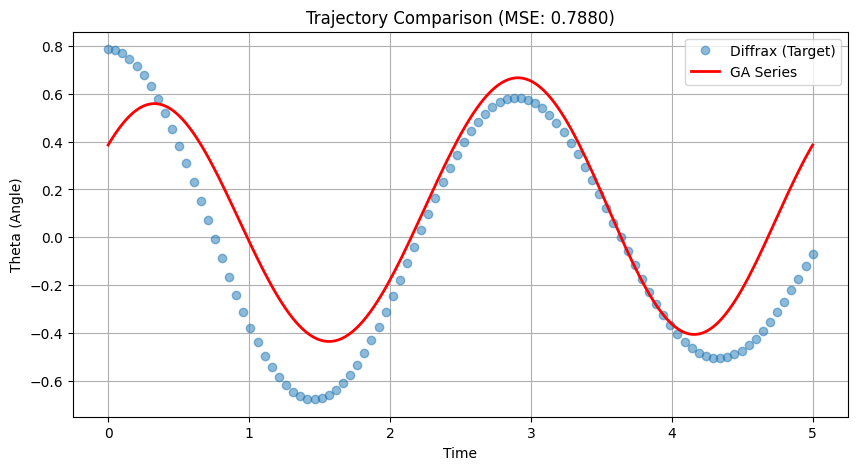

In [48]:
import matplotlib.pyplot as plt

# 1. Get the GA path over a fine time grid
plot_times = jnp.linspace(t0, t1, 200)
# Use our vmap'd state function
ga_results = jax.vmap(get_ga_state, in_axes=(0, None))(plot_times, best_coeffs)

theta_ga = ga_results[:, 0]
omega_ga = ga_results[:, 1]

# 2. Plot Position (Theta)
plt.figure(figsize=(10, 5))
plt.plot(sol.ts, sol.ys[:, 0], 'o', label='Diffrax (Target)', alpha=0.5)
plt.plot(plot_times, theta_ga, label='GA Series', color='red', linewidth=2)
plt.title(f"Trajectory Comparison (MSE: {mse:.4f})")
plt.xlabel("Time")
plt.ylabel("Theta (Angle)")
plt.legend()
plt.grid(True)
plt.show()

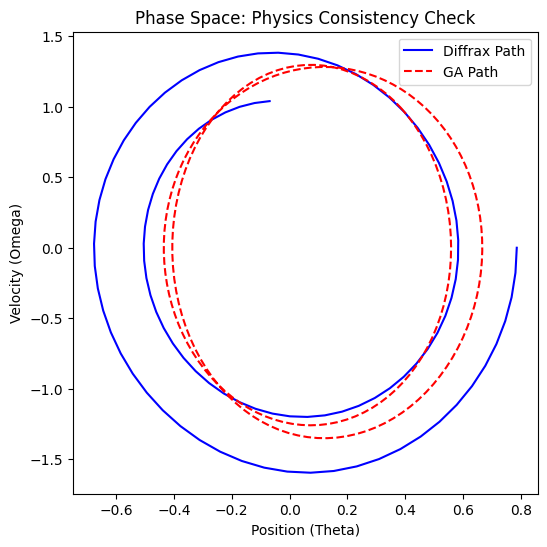

In [49]:
plt.figure(figsize=(6, 6))
plt.plot(sol.ys[:, 0], sol.ys[:, 1], label='Diffrax Path', color='blue')
plt.plot(theta_ga, omega_ga, label='GA Path', color='red', linestyle='--')
plt.xlabel("Position (Theta)")
plt.ylabel("Velocity (Omega)")
plt.title("Phase Space: Physics Consistency Check")
plt.legend()
plt.show()

In [50]:
def entropy_mutation(key, individual, base_sigma=0.05):
    # 1. Calculate "Coefficient Energy" distribution
    # We use the absolute values and normalize them like a probability distribution
    probs = jnp.abs(individual) + 1e-10
    probs = probs / jnp.sum(probs)
    
    # 2. Shannon Entropy: H = -sum(p * log(p))
    entropy = -jnp.sum(probs * jnp.log(probs))
    
    # 3. Scale Mutation: Lower entropy -> Higher noise
    # If entropy is low (near 0), mutation becomes aggressive
    # If entropy is high (complex), mutation becomes fine-tuned
    max_entropy = jnp.log(len(individual))
    scaled_sigma = base_sigma * (2.0 - (entropy / max_entropy))
    
    noise = jax.random.normal(key, shape=individual.shape) * scaled_sigma
    return individual + noise

# Example usage
key = jax.random.PRNGKey(789)
individual = jnp.array([0.5, -0.3, 0.1])
mutated_individual = entropy_mutation(key, individual)
print(f"Original: {individual}")
print(f"Mutated: {mutated_individual}") 

Original: [ 0.5 -0.3  0.1]
Mutated: [ 0.57901324 -0.28414413  0.14463682]


In [51]:
@jax.jit
def evolve_generation_fourier(key, population, fitness, base_sigma):
    pop_size = population.shape[0]
    k1, k2, k3 = jax.random.split(key, 3)
    
    # 1. Selection (Tournament or Gumbel-Max)
    parent_indices = roulette_selection(k1, fitness, pop_size)
    parents = population[parent_indices]
    
    # 2. Crossover
    half = pop_size // 2
    group_a, group_b = parents[:half], parents[half:]
    cross_keys = jax.random.split(k2, half)
    children_a, children_b = jax.vmap(uniform_crossover)(cross_keys, group_a, group_b)
    new_pop = jnp.concatenate([children_a, children_b], axis=0)
    
    # 3. Adaptive Entropy Mutation
    mut_keys = jax.random.split(k3, pop_size)
    new_pop = jax.vmap(entropy_mutation, in_axes=(0, 0, None))(mut_keys, new_pop, base_sigma)
    
    return new_pop

# Example usage
key = jax.random.PRNGKey(789)
population = jax.random.normal(key, (10, 7)) * 0.1
fitness = jnp.array([0.1, 0.5, 0.3, 0.2, 0.4, 0.6, 0.05, 0.15, 0.25, 0.35])  # Mock fitness values
base_sigma = 0.05
new_population = evolve_generation_fourier(key, population, fitness, base_sigma)
# evaluate the new population's fitness using the benchmark_harness
def evaluate_population(population, true_ts, true_ys, vf_func):
    def eval_individual(coeffs):
        mse, phys = benchmark_harness(coeffs, true_ts, true_ys, vf_func)
        return mse + phys  # Combine metrics for a single fitness score

    fitness_scores = jax.vmap(eval_individual)(population)
    return fitness_scores
# evaluate the new population
new_fitness = evaluate_population(new_population, sol.ts, sol.ys, physics_vf)
print(f"New Fitness Scores:\n{new_fitness}")

New Fitness Scores:
[1.61832137 2.68272288 1.29839394 3.68002951 0.88750137 2.90455362
 1.22223514 0.87470188 0.72618009 0.66312344]


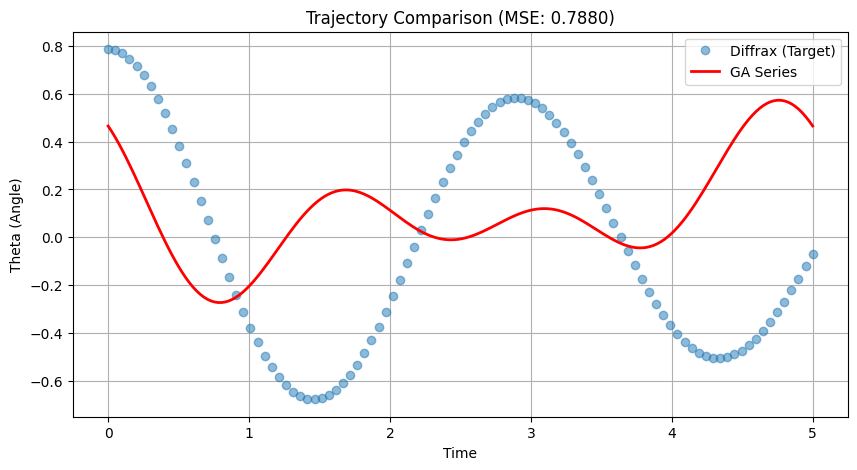

In [52]:
# 1. Get the GA path over a fine time grid
plot_times = jnp.linspace(t0, t1, 200)
ga_results = jax.vmap(get_ga_state, in_axes=(0, None))(plot_times, new_population[0])
# Evaluate the best individual
best_individual = new_population[0]
best_ga_results = jax.vmap(get_ga_state, in_axes=(0, None))(plot_times, best_individual)
#plot the results
theta_ga = best_ga_results[:, 0]
omega_ga = best_ga_results[:, 1]
plt.figure(figsize=(10, 5))
plt.plot(sol.ts, sol.ys[:, 0], 'o', label='Diffrax (Target)', alpha=0.5)
plt.plot(plot_times, theta_ga, label='GA Series', color='red', linewidth=2)
plt.title(f"Trajectory Comparison (MSE: {mse:.4f})")
plt.xlabel("Time")
plt.ylabel("Theta (Angle)")
plt.legend()
plt.grid(True)
plt.show()  
